# Import data

In [666]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


import warnings
warnings.filterwarnings("ignore")

In [667]:
df = pd.read_csv('StudentsPerformance.csv')

# Data Size

In [668]:
print(df.shape)

(1000, 8)


In [669]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   midterm score                1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [670]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,midterm score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [671]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,midterm score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [672]:
df.describe()
# thống kê int64
# mean: trung bình điểm 
# std: độ lệch chuẩn
# min: điểm thấp nhất
# 25%: 25% học sinh có điểm thấp hơn giá trị này
# 50%: 50% học sinh có điểm thấp hơn giá trị này (trung vị)
# 75%: 75% học sinh có điểm thấp hơn giá trị này
# max: điểm cao nhất

,midterm score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Add New Columns - "Average_score" and "Result" 

In [673]:
df['Average_score'] = (
    0.2 * df['midterm score'] +
    0.4 * df['reading score'] +
    0.4 * df['writing score']
)
# tính điểm trung bình của học sinh

In [674]:
print(df['Average_score'].head())

0    72.8
1    85.0
2    93.2
3    49.8
4    76.4
Name: Average_score, dtype: float64


In [675]:
df['Result'] = df['Average_score'].apply(lambda x: 'Passed' if x >= 50 else 'Failed')
# Tạo cột Result với điều kiện nếu Average_score >= 50 thì Passed, ngược lại Failed

In [676]:
print(df['Result'].head())
print(df['Result'].tail())


0    Passed
1    Passed
2    Passed
3    Failed
4    Passed
Name: Result, dtype: object
995    Passed
996    Passed
997    Passed
998    Passed
999    Passed
Name: Result, dtype: object


In [677]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   midterm score                1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Average_score                1000 non-null   float64
 9   Result                       1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB


# EDA

<Axes: xlabel='midterm score', ylabel='Count'>

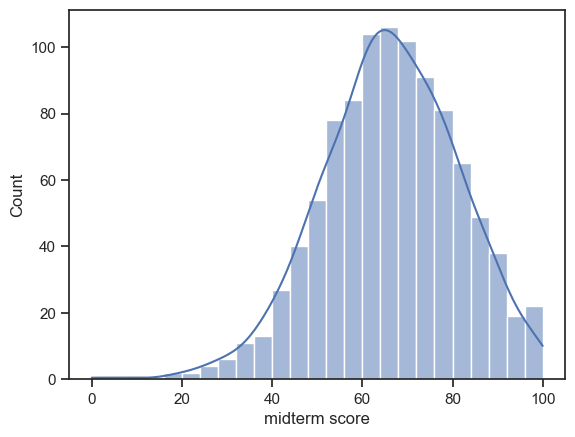

In [678]:
sns.set_theme(style="ticks")
sns.histplot(data=df, x="midterm score", kde=True)
# Đồ thị phân phối điểm toán của học sinh

<Axes: xlabel='reading score', ylabel='Count'>

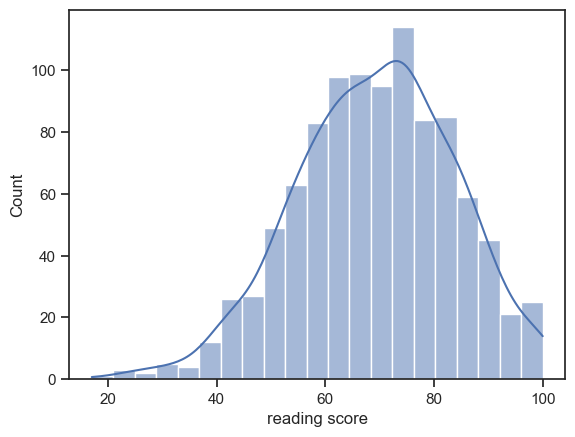

In [679]:
sns.set_theme(style="ticks")
sns.histplot(data=df, x="reading score", kde=True)

<Axes: xlabel='writing score', ylabel='Count'>

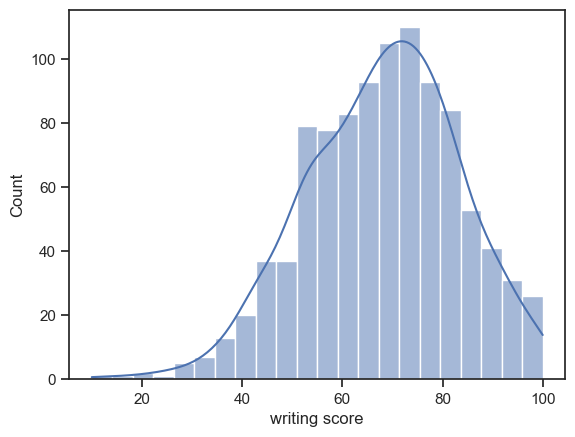

In [680]:
sns.set_theme(style="ticks")
sns.histplot(data=df, x="writing score", kde=True)

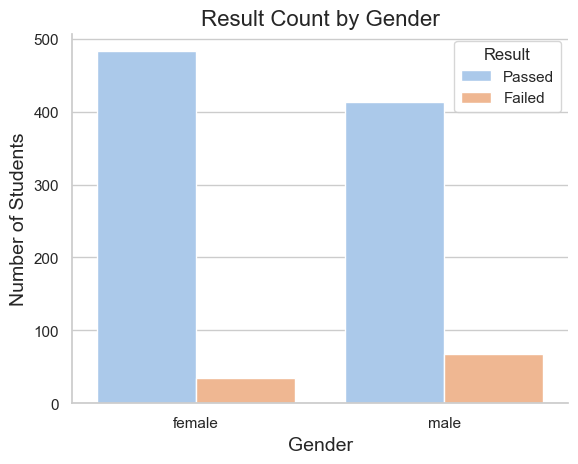

In [681]:
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='gender', hue='Result', palette='pastel')
plt.title('Result Count by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Number of Students', fontsize=14)

sns.despine()
plt.show()

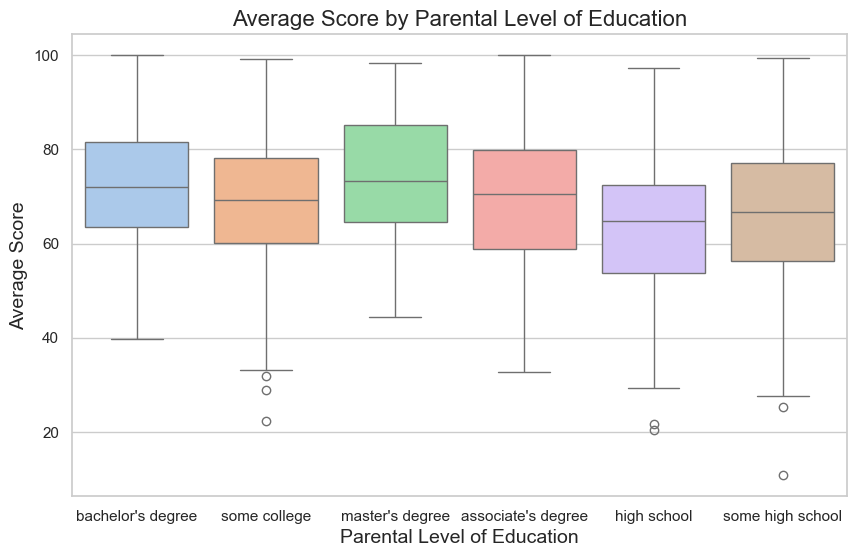

In [682]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df, x="parental level of education", y="Average_score", palette="pastel")
plt.title('Average Score by Parental Level of Education', fontsize=16) 
plt.xlabel('Parental Level of Education', fontsize=14)
plt.ylabel('Average Score', fontsize=14)
plt.show()
# Đồ thị boxplot cho thấy điểm trung bình của học sinh phụ thuộc vào trình độ học vấn của cha mẹ.
# Cha mẹ có trình độ học vấn cao hơn thì điểm trung bình của học sinh cũng cao hơn.

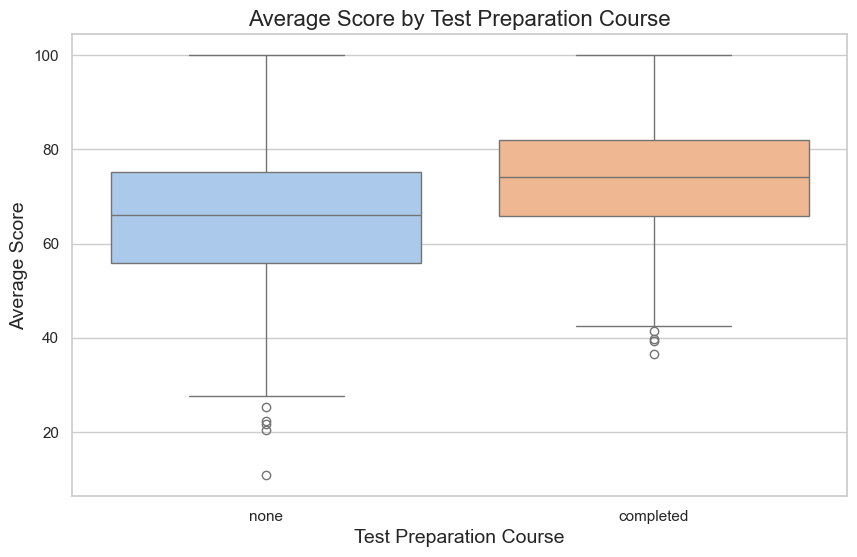

In [683]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.boxplot(data=df, x='test preparation course', y='Average_score', palette='pastel')
plt.title('Average Score by Test Preparation Course', fontsize=16)
plt.xlabel('Test Preparation Course', fontsize=14)
plt.ylabel('Average Score', fontsize=14)
plt.show()

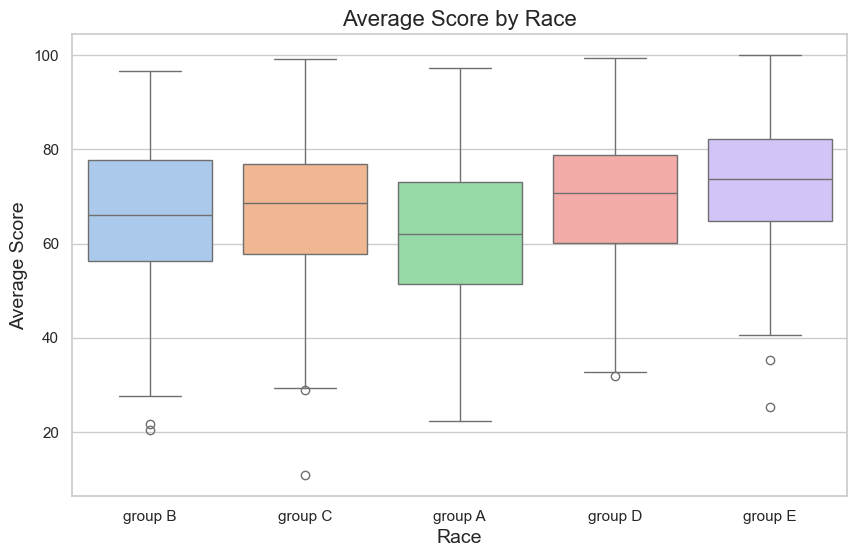

In [684]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='race/ethnicity', y='Average_score', palette='pastel')
plt.title('Average Score by Race', fontsize=16)
plt.xlabel('Race', fontsize=14)
plt.ylabel('Average Score', fontsize=14)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

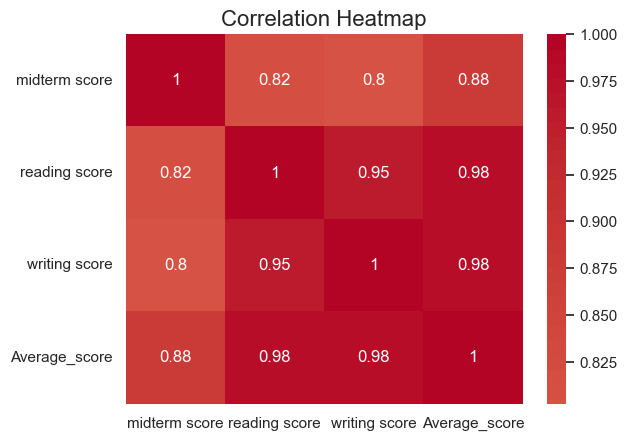

In [685]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=16)
# biểu đồ heatmap : phân tích mối tương quan giữa các biến số trong dataframe
# math : tăng 1 điểm thì reading cũng tăng 0.82 điểm 
# ví dụ: toán 3 ->4 thì reading 3->3.82, reading 3->4 thì toán 3->3.82

# Data Preprocessing

### Check Missing Value and Duplicate Data

In [686]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
midterm score                  0
reading score                  0
writing score                  0
Average_score                  0
Result                         0
dtype: int64

In [687]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### Handle Categorical features


In [688]:
df.info()
# từ object -> int64, float64 trình độ bố mẹ chuyên sang số, giới tính sang số


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   midterm score                1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Average_score                1000 non-null   float64
 9   Result                       1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB


### Gender

In [689]:
df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else 1)

### race/ethnicity

In [690]:
# In các giá trị unique trong cột 'education'
unique_values = df['race/ethnicity'].unique()
print(unique_values)

['group B' 'group C' 'group A' 'group D' 'group E']


In [691]:
race_map = {
    'group A': 1,
    'group B': 2,
    'group C': 3,
    'group D': 4,
    'group E': 5
}

# Áp dụng mapping cho cột 'gender'
df['race/ethnicity'] = df['race/ethnicity'].map(race_map)

In [692]:
unique_values = df['race/ethnicity'].unique()
print(unique_values)

[2 3 1 4 5]


### parental level of education

In [693]:
# In các giá trị unique trong cột 'education'
unique_values = df['parental level of education'].unique()
print(unique_values)

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [694]:
race_map = {
    "bachelor's degree": 1,
    'some college': 2,
    "master's degree": 3,
    "associate's degree": 4,
    'high school': 5,
    'some high school': 6
}

# Áp dụng mapping cho cột 'gender'
df['parental level of education'] = df['parental level of education'].map(race_map)

In [695]:
unique_values = df['parental level of education'].unique()
print(unique_values)

[1 2 3 4 5 6]


### lunch

In [696]:
# In các giá trị unique trong cột 'education'
unique_values = df['lunch'].unique()
print(unique_values)

['standard' 'free/reduced']


In [697]:
race_map = {
    'standard': 1,
    'free/reduced': 0
}

# Áp dụng mapping cho cột 'gender'
df['lunch'] = df['lunch'].map(race_map)

In [698]:
unique_values = df['lunch'].unique()
print(unique_values)

[1 0]


### test preparation course

In [699]:
# In các giá trị unique trong cột 'education'
unique_values = df['test preparation course'].unique()
print(unique_values)

['none' 'completed']


In [700]:
race_map = {
    'none': 0,
    'completed': 1
}

# Áp dụng mapping cho cột 'gender'
df['test preparation course'] = df['test preparation course'].map(race_map)

In [701]:
# In các giá trị unique trong cột 'education'
unique_values = df['test preparation course'].unique()
print(unique_values)

[0 1]


In [702]:
# In các giá trị unique trong cột 'education'
unique_values = df['Result'].unique()
print(unique_values)

['Passed' 'Failed']


In [703]:
race_map = {
    'Passed': 1,
    'Failed': 0
}

# Áp dụng mapping cho cột 'gender'
df['Result'] = df['Result'].map(race_map)

In [704]:
# In các giá trị unique trong cột 'education'
unique_values = df['Result'].unique()
print(unique_values)

[1 0]


In [705]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   int64  
 1   race/ethnicity               1000 non-null   int64  
 2   parental level of education  1000 non-null   int64  
 3   lunch                        1000 non-null   int64  
 4   test preparation course      1000 non-null   int64  
 5   midterm score                1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Average_score                1000 non-null   float64
 9   Result                       1000 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 78.3 KB


In [706]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,midterm score,reading score,writing score,Average_score,Result
0,0,2,1,1,0,72,72,74,72.8,1
1,0,3,2,1,1,69,90,88,85.0,1
2,0,2,3,1,0,90,95,93,93.2,1
3,1,1,4,0,0,47,57,44,49.8,0
4,1,3,2,1,0,76,78,75,76.4,1


Text(0.5, 1.0, 'Distribution of Students by Result')

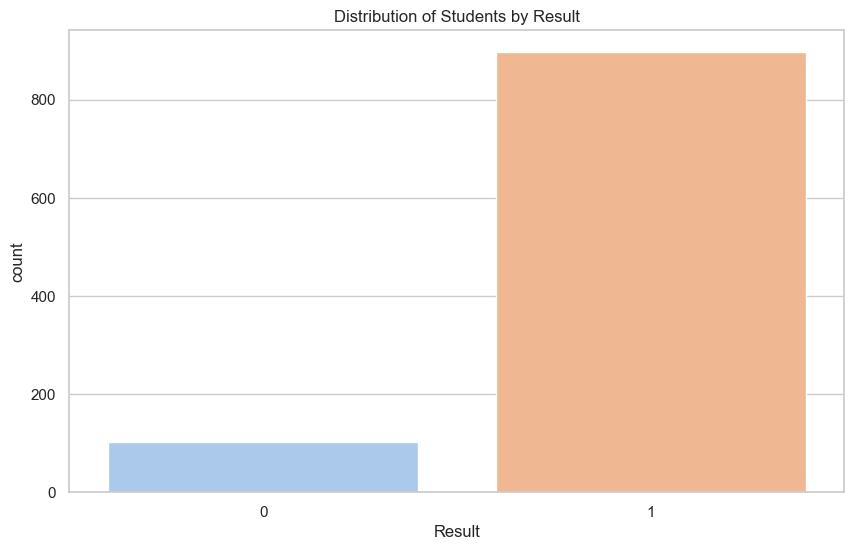

In [707]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Result', palette='pastel')
plt.title('Distribution of Students by Result')
# mất cân bằng giữa Passed và Failed

In [708]:
df = df.drop(columns=['Average_score'])
# Để học máy không bị ảnh hưởng bởi Average_score, ta sẽ xóa cột này đi

In [709]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,midterm score,reading score,writing score,Result
0,0,2,1,1,0,72,72,74,1
1,0,3,2,1,1,69,90,88,1
2,0,2,3,1,0,90,95,93,1
3,1,1,4,0,0,47,57,44,0
4,1,3,2,1,0,76,78,75,1
...,...,...,...,...,...,...,...,...,...
995,0,5,3,1,1,88,99,95,1
996,1,3,5,0,0,62,55,55,1
997,0,3,5,0,1,59,71,65,1
998,0,4,2,1,1,68,78,77,1


# Build Model

## Upsampling using SMOTE method, Scale using MinMax

In [710]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

In [711]:
# SMOTE and Scale
X = df.drop(columns=['Result', 'reading score', 'writing score'])  # Loại bỏ các cột điểm
y = df['Result']  # Chọn cột Result làm output

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 1 1 1 0 0 0 0 0 0 0 0 0 
sm = SMOTE(k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
# Chỉ cho dữ liệu train, 0 được cho test
X_train_res.shape, y_train_res.shape

scaler = MinMaxScaler()
# Chuyển đổi dữ liệu về khoảng [0, 1] => Giúp cho các thuật toán học máy hoạt động tốt hơn
X_train_res = scaler.fit_transform(X_train_res)
#fit_transform: vừa fit vừa transform
# fit: tìm ra các thông số cần thiết để chuyển đổi dữ liệu
X_test = scaler.transform(X_test)
#transform: chuyển đổi dữ liệu theo các thông số đã tìm được ở bước fit

In [712]:
y_train_res.size  # Total number of elements in the array

1446

In [713]:
print(X_test)

[[0.         0.5        0.6        1.         0.         0.90217391]
 [0.         0.25       0.2        0.         1.         0.48913043]
 [1.         0.75       0.         1.         0.         0.7826087 ]
 ...
 [0.         0.25       0.2        0.         0.         0.7173913 ]
 [0.         0.5        0.6        1.         0.         0.61956522]
 [0.         0.75       1.         1.         1.         0.57608696]]


Text(0.5, 1.0, 'Distribution of Students by Result')

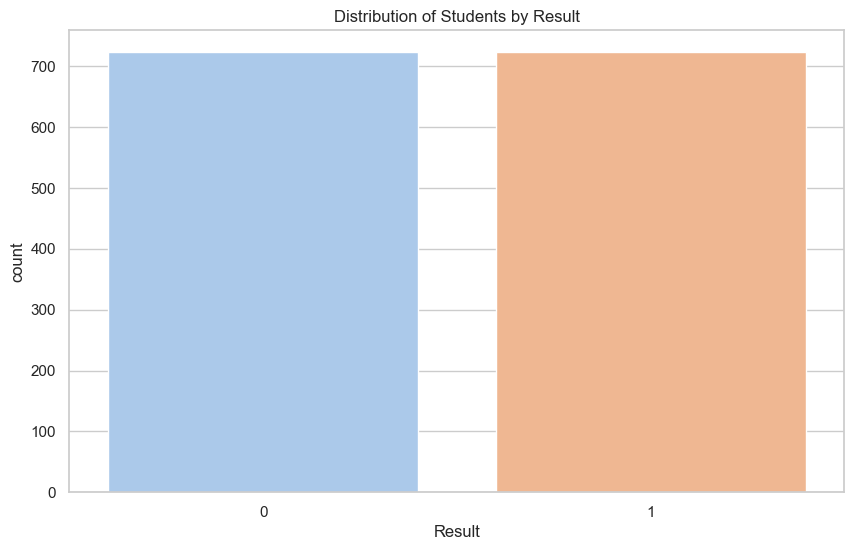

In [714]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=y_train_res, palette='pastel')
plt.title('Distribution of Students by Result')

## Logistic Regression

Logistic Regression
              precision    recall  f1-score   support

           0       0.57      0.92      0.71        26
           1       0.99      0.90      0.94       174

    accuracy                           0.90       200
   macro avg       0.78      0.91      0.82       200
weighted avg       0.93      0.90      0.91       200



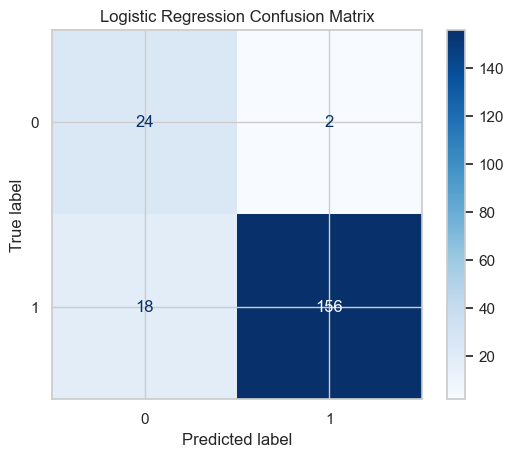

In [715]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

model_logistic = LogisticRegression()
model_logistic.fit(X_train_res, y_train_res)
y_pred_logistic = model_logistic.predict(X_test)

# Logistic Regression Evaluation
print("Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model_logistic, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# RandomForest

Random Forest
              precision    recall  f1-score   support

           0       0.60      0.69      0.64        26
           1       0.95      0.93      0.94       174

    accuracy                           0.90       200
   macro avg       0.78      0.81      0.79       200
weighted avg       0.91      0.90      0.90       200



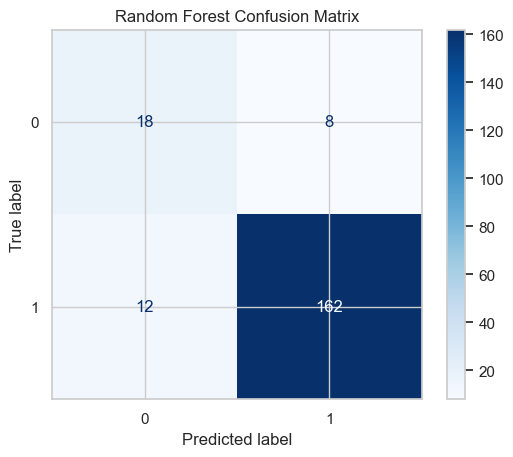

In [716]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_res, y_train_res)
y_pred_rf = model_rf.predict(X_test)

# Random Forest Evaluation
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix')
plt.show()



# SVM Model

SVM
              precision    recall  f1-score   support

           0       0.59      0.92      0.72        26
           1       0.99      0.90      0.94       174

    accuracy                           0.91       200
   macro avg       0.79      0.91      0.83       200
weighted avg       0.94      0.91      0.91       200



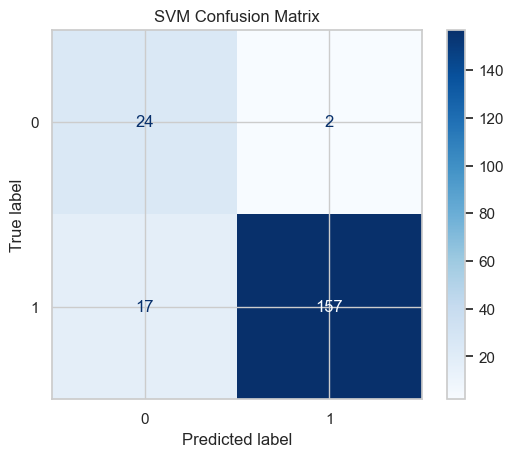

In [717]:
from sklearn.svm import SVC
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_res, y_train_res)
y_pred_svm = model_svm.predict(X_test)
# SVM Evaluation
print("SVM")
print(classification_report(y_test, y_pred_svm))
# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model_svm, X_test, y_test, cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()

In [718]:
import joblib

# Sau khi đã huấn luyện model tốt nhất (ví dụ: model_rf)
joblib.dump(model_rf, 'student_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']